In [1]:
import pandas as pd

# Load Sensor Logs- Already in IST

In [ ]:
logs = pd.read_json('manan_logs.jsonl', lines = True)

In [3]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [5]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-06 02:15:41.769366800+05:30,47.0,74,46.2,2520.0,67.89,122,281
1,2026-07-06 02:15:44.600078900+05:30,13.9,60,12.1,1423.8,68.49,124,281
2,2026-07-06 02:15:46.669384600+05:30,14.3,60,13.5,1505.7,68.46,125,281
3,2026-07-06 02:15:48.720379100+05:30,22.4,62,13.6,1341.9,68.60,125,281
4,2026-07-06 02:15:50.768410800+05:30,29.2,65,27.1,1757.7,68.92,125,283


# Load Stress Events - UTC Format (Z)

In [6]:
events = pd.read_json("manan_stress_events.jsonl", lines = True)

In [7]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [8]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Manan_2026-07-05T20-45-51-776584600Z,Manan,SYSTEM,0,0,2026-07-06 02:15:51.792922600+05:30,2026-07-06 02:15:51.792922600+05:30,0,201,Automatic stress experiment started.
1,SESSION,Manan_2026-07-05T20-45-51-776584600Z,Manan,INITIAL_IDLE,0,0,2026-07-06 02:15:51.798922600+05:30,2026-07-06 02:17:51.800501700+05:30,120,201,Idle or cooling session completed.
2,WORKLOAD_STEP,Manan_2026-07-05T20-45-51-776584600Z,Manan,RAMP,0,1,2026-07-06 02:17:51.810536800+05:30,2026-07-06 02:18:50.812542+05:30,59,201,Completed workload step.
3,WORKLOAD_STEP,Manan_2026-07-05T20-45-51-776584600Z,Manan,RAMP,0,2,2026-07-06 02:18:50.813533600+05:30,2026-07-06 02:21:45.814888+05:30,175,201,Completed workload step.
4,WORKLOAD_STEP,Manan_2026-07-05T20-45-51-776584600Z,Manan,RAMP,20,3,2026-07-06 02:21:45.814888+05:30,2026-07-06 02:22:57.817973700+05:30,72,201,Completed workload step.


In [9]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [10]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [11]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-06 02:15:41.769366800+05:30,47.0,74,46.2,2520.0,67.89,122,281
1,2026-07-06 02:15:44.600078900+05:30,13.9,60,12.1,1423.8,68.49,124,281
2,2026-07-06 02:15:46.669384600+05:30,14.3,60,13.5,1505.7,68.46,125,281
3,2026-07-06 02:15:48.720379100+05:30,22.4,62,13.6,1341.9,68.60,125,281
4,2026-07-06 02:15:50.768410800+05:30,29.2,65,27.1,1757.7,68.92,125,283


In [12]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Manan_2026-07-05T20-45-51-776584600Z,Manan,SYSTEM,0,0,2026-07-06 02:15:51.792922600+05:30,2026-07-06 02:15:51.792922600+05:30,0,201,Automatic stress experiment started.
1,RUN,Manan_2026-07-05T20-45-51-776584600Z,Manan,COMPLETE_EXPERIMENT,0,0,2026-07-06 02:15:51.792922600+05:30,2026-07-06 10:12:51.830109400+05:30,28620,201,Experiment completed normally.
2,SESSION,Manan_2026-07-05T20-45-51-776584600Z,Manan,INITIAL_IDLE,0,0,2026-07-06 02:15:51.798922600+05:30,2026-07-06 02:17:51.800501700+05:30,120,201,Idle or cooling session completed.
3,SESSION,Manan_2026-07-05T20-45-51-776584600Z,Manan,RAMP,0,61,2026-07-06 02:17:51.810536800+05:30,2026-07-06 03:47:51.813279300+05:30,5400,201,Workload session completed.
4,WORKLOAD_STEP,Manan_2026-07-05T20-45-51-776584600Z,Manan,RAMP,0,1,2026-07-06 02:17:51.810536800+05:30,2026-07-06 02:18:50.812542+05:30,59,201,Completed workload step.


In [13]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-06 02:15:41.769366800+05:30
Sensor end:   2026-07-06 10:37:41.398775800+05:30


In [14]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-06 02:15:51.792922600+05:30
Event end:   2026-07-06 10:12:51.832106800+05:30


In [15]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [16]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                 runId deviceId                 mode  targetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  Manan_2026-07-05T20-45-51-776584600Z    Manan               SYSTEM           0           0 2026-07-06 02:15:51.792922600+05:30 2026-07-06 02:15:51.792922600+05:30                      0   201  Automatic stress experiment started.
1            RUN  Manan_2026-07-05T20-45-51-776584600Z    Manan  COMPLETE_EXPERIMENT           0           0 2026-07-06 02:15:51.792922600+05:30 2026-07-06 10:12:51.830109400+05:30                  28620   201        Experiment completed normally.
2        SESSION  Manan_2026-07-05T20-45-51-776584600Z    Manan         INITIAL_IDLE           0           0 2026-07-06 02:15:51.798922600+05:30 2026-07-06 02:17:51.800501700+05:30                    120   201    Idle or cooling session completed.
3       

# Cleaning the Stress Intervals

In [17]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 310


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-06 02:15:51.792922600+05:30,2026-07-06 10:12:51.830109400+05:30,COMPLETE_EXPERIMENT,0,0,RUN
1,2026-07-06 02:15:51.798922600+05:30,2026-07-06 02:17:51.800501700+05:30,INITIAL_IDLE,0,0,SESSION
2,2026-07-06 02:17:51.810536800+05:30,2026-07-06 03:47:51.813279300+05:30,RAMP,0,61,SESSION
3,2026-07-06 02:17:51.810536800+05:30,2026-07-06 02:18:50.812542+05:30,RAMP,0,1,WORKLOAD_STEP
4,2026-07-06 02:18:50.813533600+05:30,2026-07-06 02:21:45.814888+05:30,RAMP,0,2,WORKLOAD_STEP
5,2026-07-06 02:21:45.814888+05:30,2026-07-06 02:22:57.817973700+05:30,RAMP,20,3,WORKLOAD_STEP
6,2026-07-06 02:22:57.818972100+05:30,2026-07-06 02:24:17.821413900+05:30,RAMP,20,4,WORKLOAD_STEP
7,2026-07-06 02:24:17.821413900+05:30,2026-07-06 02:24:37.824072600+05:30,RAMP,40,5,WORKLOAD_STEP
8,2026-07-06 02:24:37.825048500+05:30,2026-07-06 02:26:14.825994+05:30,RAMP,40,6,WORKLOAD_STEP
9,2026-07-06 02:26:14.827182200+05:30,2026-07-06 02:27:28.829130100+05:30,RAMP,60,7,WORKLOAD_STEP


In [39]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 300
Idle/cooling sessions: 5

Workload modes:
mode
MIXED         120
CHAOS          64
RAMP           61
TRANSITION     55
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                1
COOLING_AFTER_RAMP          1
COOLING_AFTER_CHAOS         1
COOLING_AFTER_TRANSITION    1
FINAL_COOLING               1
Name: count, dtype: int64


In [19]:
import numpy as np

In [40]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ============================================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"

In [41]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (14803, 12)

Mode distribution:
mode
MIXED                       5298
CHAOS                       2658
RAMP                        2656
TRANSITION                  2654
UNASSIGNED                   739
FINAL_COOLING                296
COOLING_AFTER_CHAOS          148
COOLING_AFTER_TRANSITION     148
COOLING_AFTER_RAMP           147
INITIAL_IDLE                  59
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13266
SESSION            798
None               739
Name: count, dtype: int64

Unassigned samples:
739


In [42]:
experiment_start = events.loc[
    events["eventType"] == "RUN",
    "startTime"
].iloc[0]

experiment_end = events.loc[
    events["eventType"] == "RUN",
    "endTime"
].iloc[0]


merged.loc[
    merged["timestamp"] < experiment_start,
    "mode"
] = "PRE_EXPERIMENT"


merged.loc[
    merged["timestamp"] >= experiment_end,
    "mode"
] = "POST_EXPERIMENT"

In [22]:
merged.to_csv(
    "manan_merged_experiment.csv",
    index=False
)

print("Saved: manan_merged_experiment.csv")

Saved: manan_merged_experiment.csv


In [23]:
import matplotlib.pyplot as plt

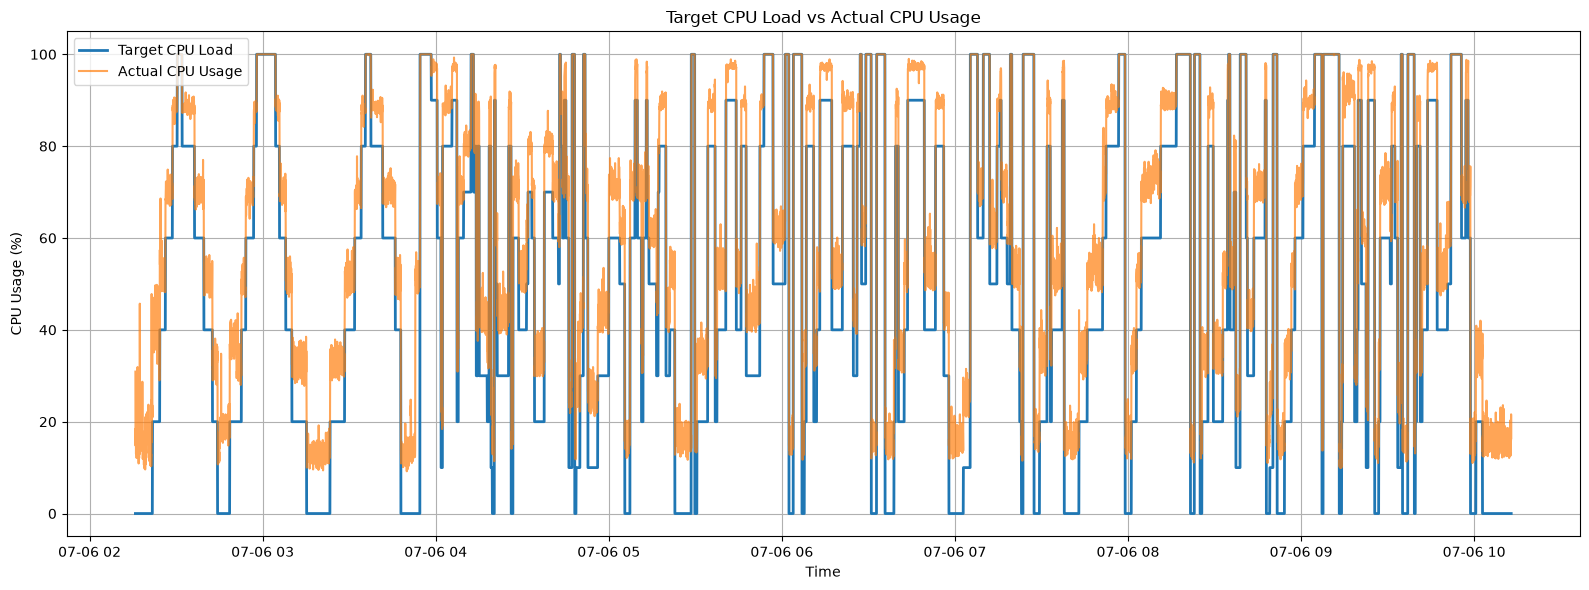

In [24]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 11.16420648464164
Correlation: 0.9802894653140243


In [26]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,2357,17.117650,8.556173,69.976665
1,10.0,406,26.379064,5.735941,71.921182
2,20.0,1577,34.691566,4.929638,76.419784
3,30.0,716,44.345810,4.575394,85.212291
4,40.0,1677,52.657961,4.009836,89.681574
5,50.0,543,62.176059,4.003096,93.414365
6,60.0,1836,71.018519,3.333713,95.978214
7,70.0,245,80.283673,2.730876,96.342857
8,80.0,1889,88.814029,4.398082,94.605611
9,90.0,854,96.509836,4.909886,96.442623


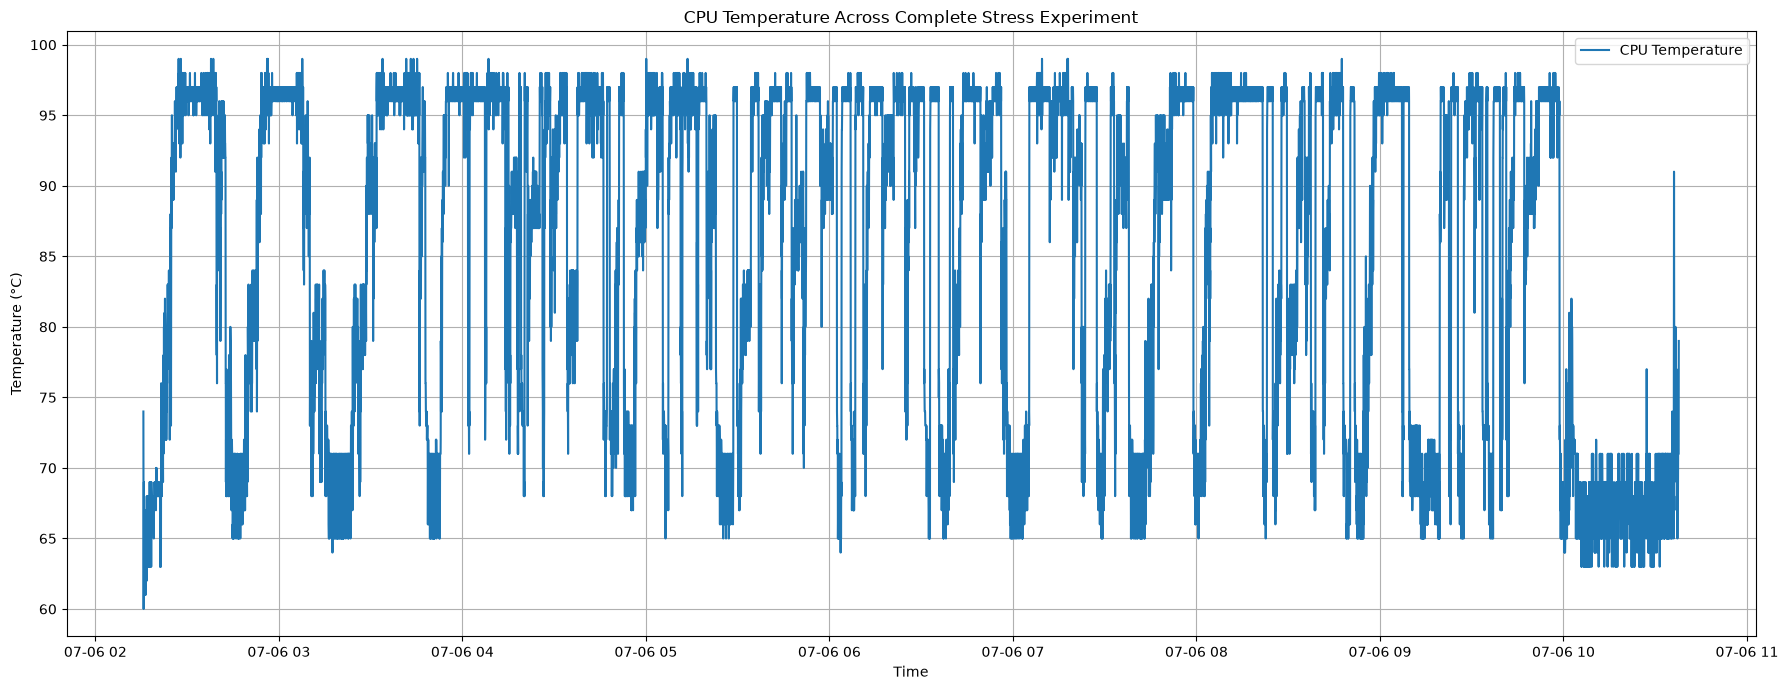

In [27]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-06 02:15:41.769366800+05:30,UNASSIGNED
5,2026-07-06 02:15:52.811050700+05:30,INITIAL_IDLE
64,2026-07-06 02:17:52.834077200+05:30,RAMP
2720,2026-07-06 03:47:53.510465900+05:30,COOLING_AFTER_RAMP
2867,2026-07-06 03:52:52.141073800+05:30,CHAOS
5525,2026-07-06 05:22:52.613301500+05:30,COOLING_AFTER_CHAOS
5673,2026-07-06 05:27:53.169679800+05:30,TRANSITION
8327,2026-07-06 06:57:53.351794300+05:30,COOLING_AFTER_TRANSITION
8475,2026-07-06 07:02:53.864266600+05:30,MIXED
13773,2026-07-06 10:02:51.863290500+05:30,FINAL_COOLING


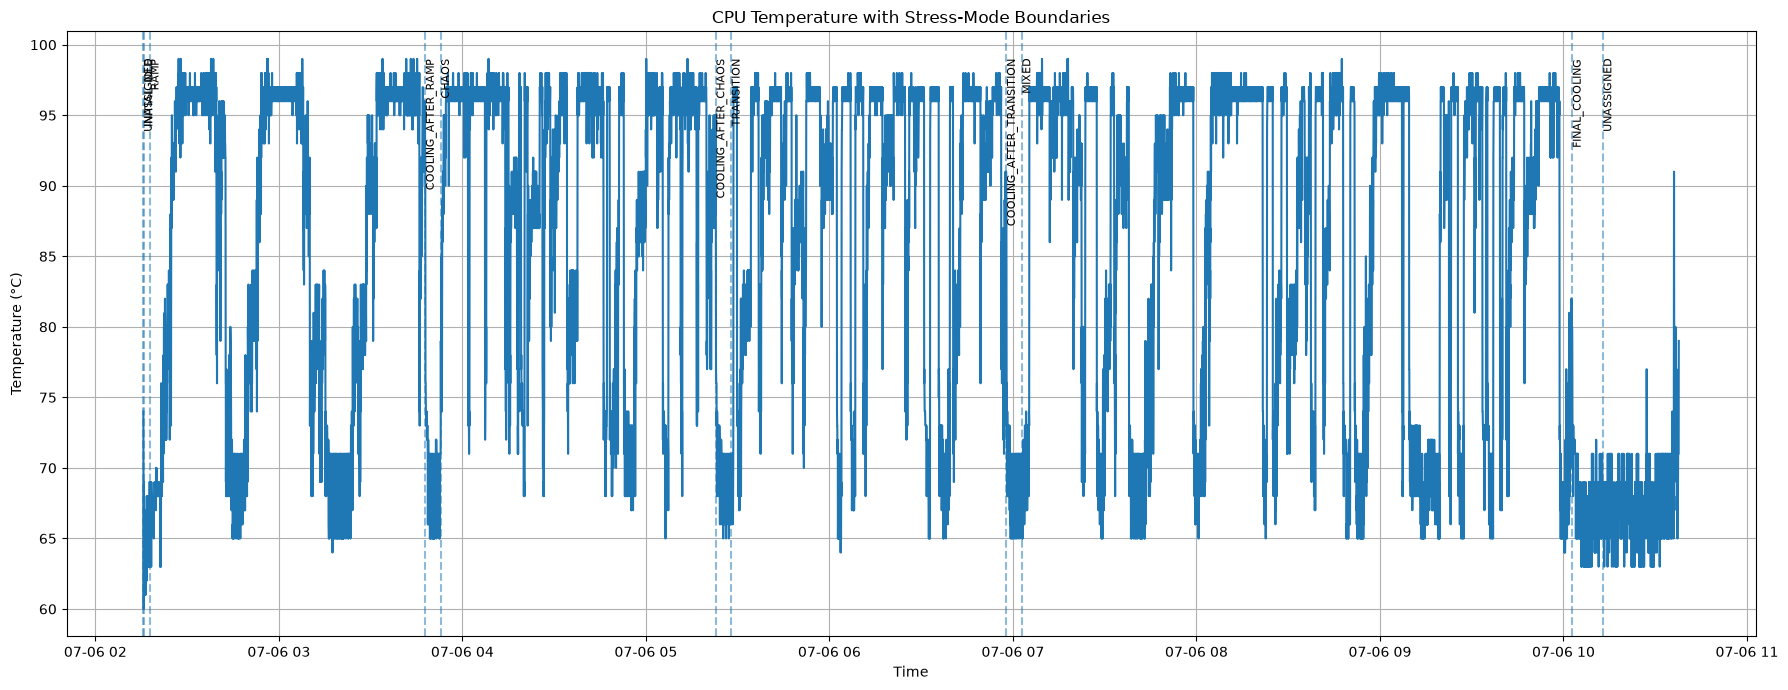

In [29]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
analysis_cols = [
    "cpuUsage",
    "cpuPackagePower",
    "cpuAverageClock",
    "cpuTemperature"
]

correlation = (
    merged[analysis_cols]
    .corr()
)

display(correlation)

,cpuUsage,cpuPackagePower,cpuAverageClock,cpuTemperature
cpuUsage,1.000000,0.887819,0.741562,0.856950
cpuPackagePower,0.887819,1.000000,0.906653,0.966460
cpuAverageClock,0.741562,0.906653,1.000000,0.910249
cpuTemperature,0.856950,0.966460,0.910249,1.000000


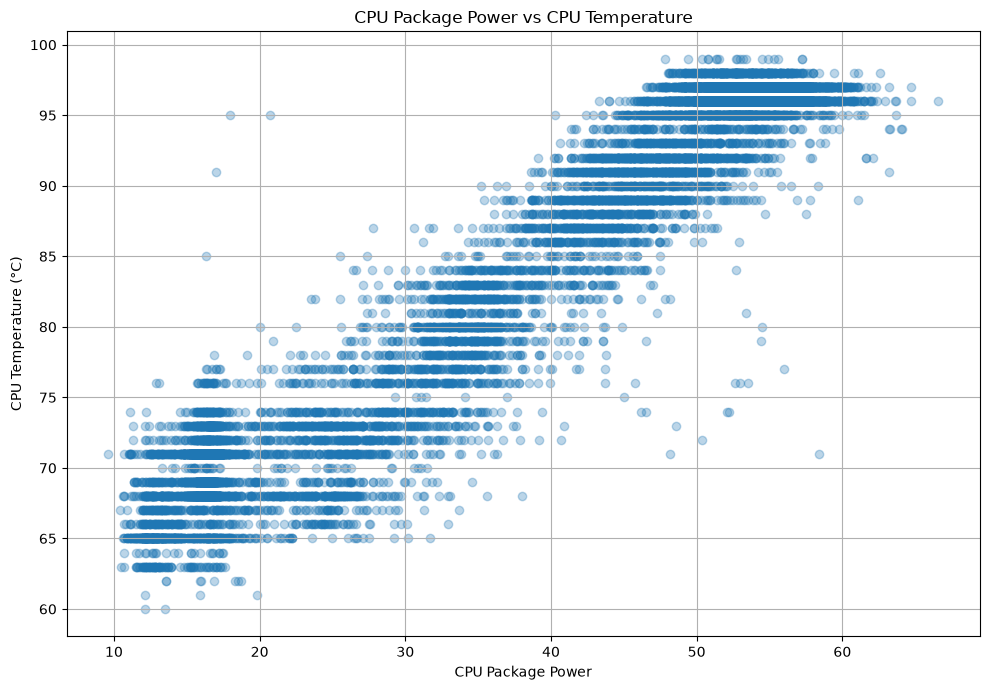

In [32]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

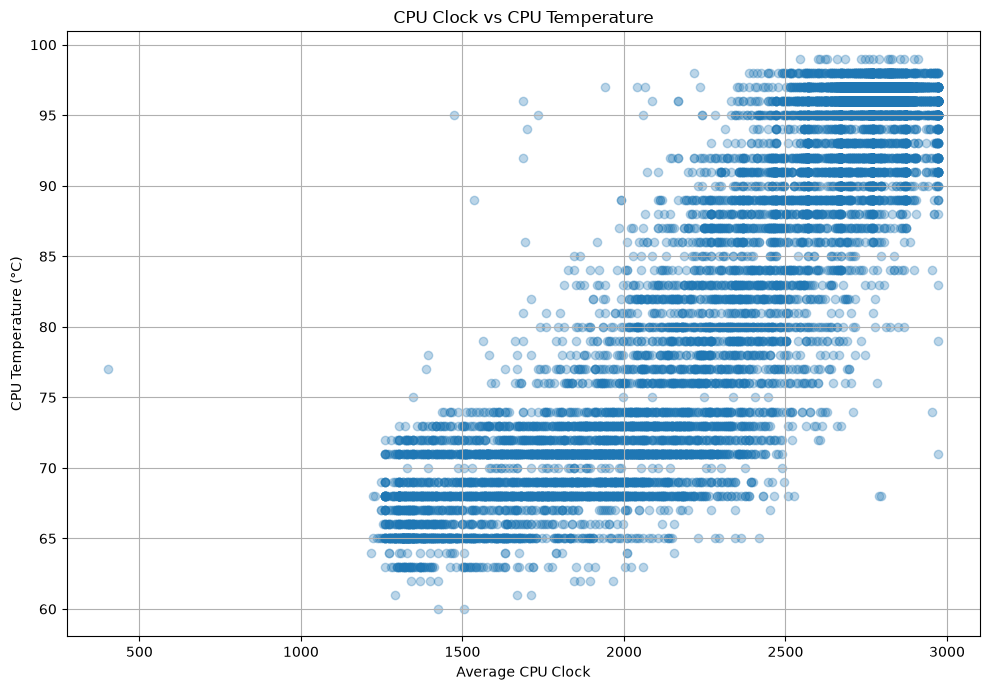

In [33]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

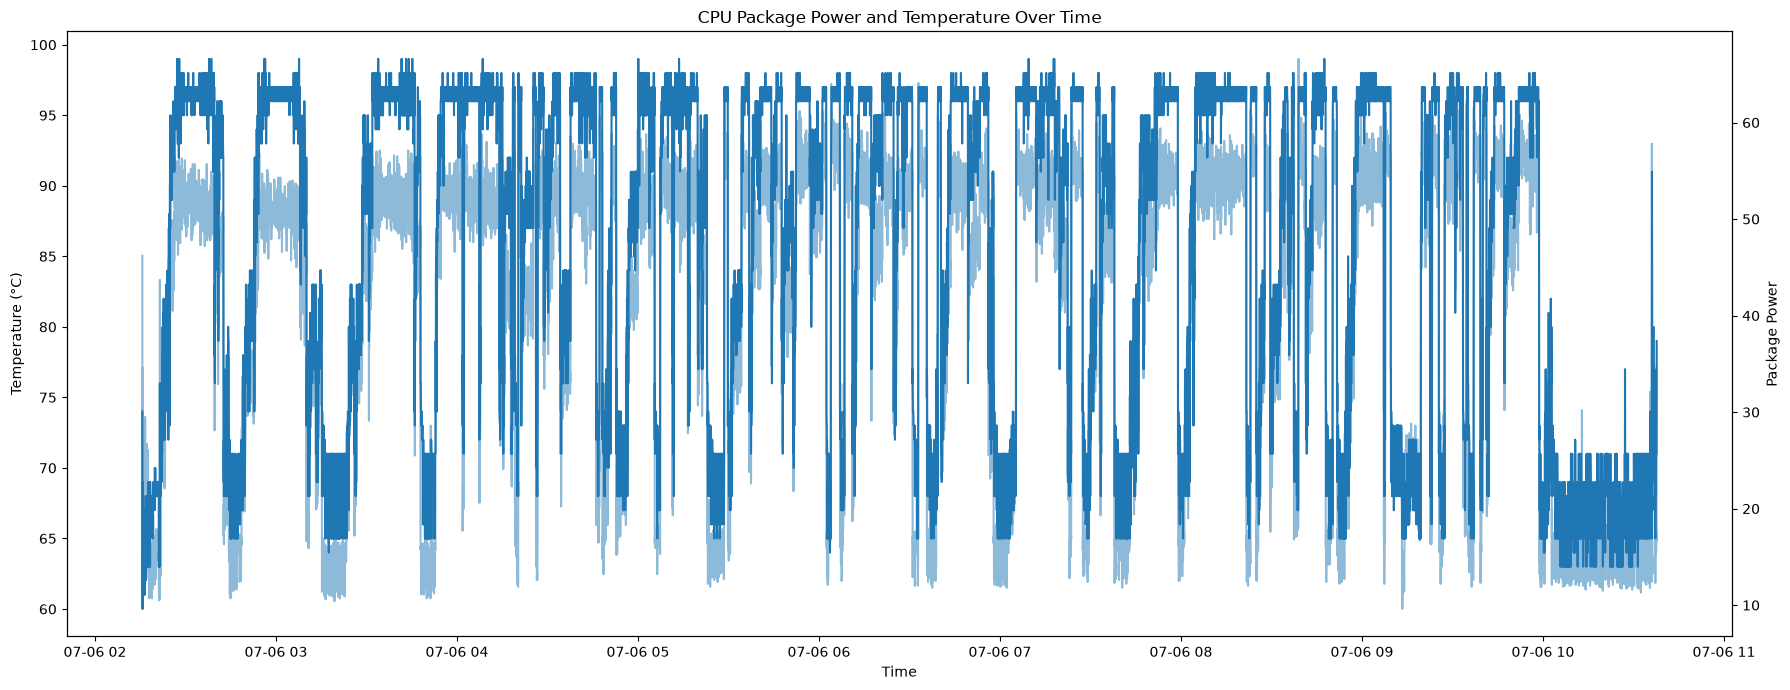

In [34]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [35]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 739
mode
FINAL_COOLING               296
COOLING_AFTER_CHAOS         148
COOLING_AFTER_TRANSITION    148
COOLING_AFTER_RAMP          147
Name: count, dtype: int64


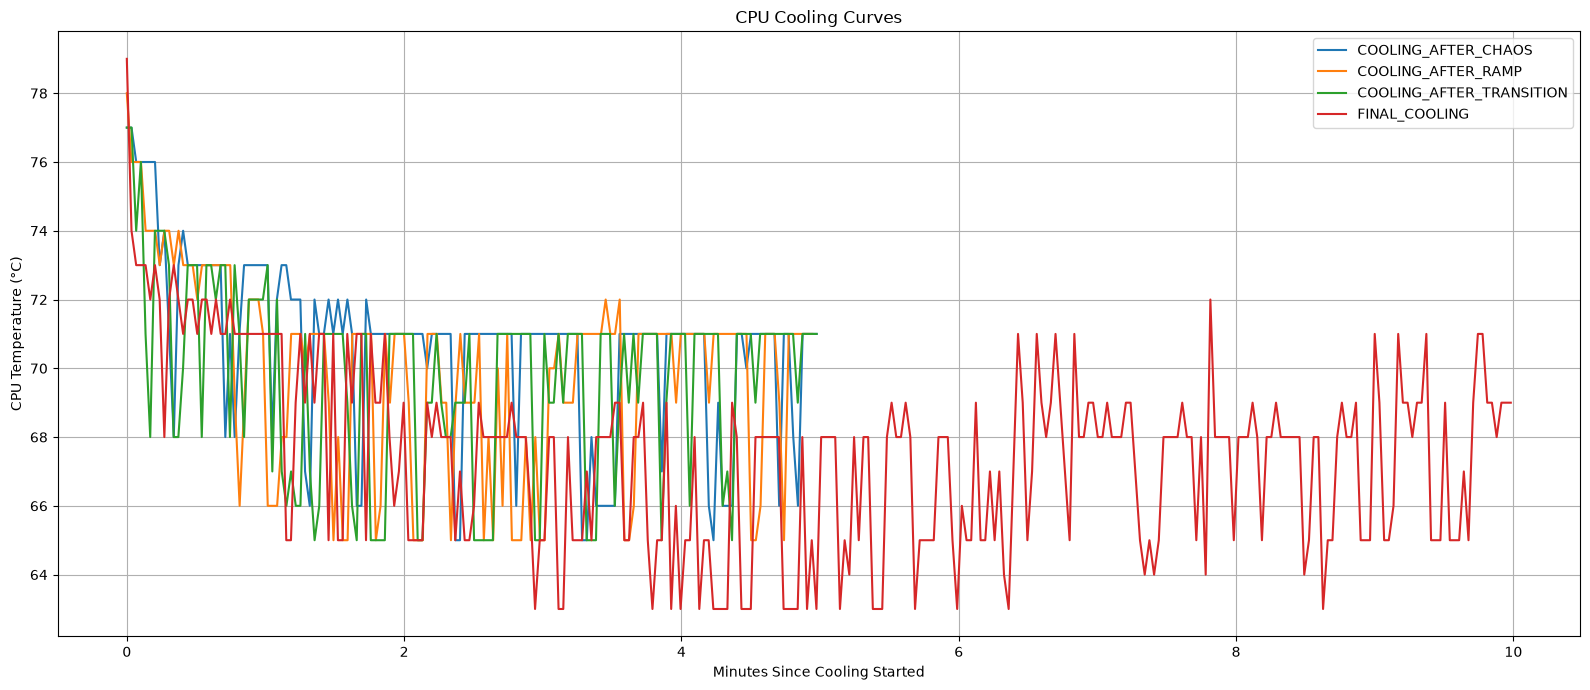

In [37]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,77,71,6,4.975488,1.205912
1,COOLING_AFTER_RAMP,78,71,7,4.943327,1.416050
2,COOLING_AFTER_TRANSITION,77,71,6,4.974529,1.206144
3,FINAL_COOLING,79,69,10,9.981336,1.001870
